Perfect — here’s a **clean, hands‑on example** you can **run, modify, and practice**, using **realistic networking concepts** and the **same type structure**:

```python
List[Dict[str, Dict[str, List[WanDevice]]]]
```

I’ll keep it **simple, realistic, and test‑friendly**, like SWAN / WAN steering code.

***

## 1️⃣ Define a simple `WanDevice` (network-style)

```python
from dataclasses import dataclass

@dataclass
class WanDevice:
    name: str
    vendor: str
    site: str

    def __str__(self):
        return f"{self.name} ({self.vendor}, {self.site})"
```

This represents a WAN router / DUT.

***

## 2️⃣ Create `all_paths_info` with the exact same type

```python
from typing import Dict, List

# Type alias (best practice)
PathInfo = Dict[str, Dict[str, List[WanDevice]]]

all_paths_info: List[PathInfo] = [
    {
        "siteA-siteB": {
            "primary": [
                WanDevice("r1", "cisco", "siteA"),
                WanDevice("r2", "juniper", "siteB"),
            ],
            "backup": [
                WanDevice("r3", "arista", "siteA")
            ],
        }
    },
    {
        "siteA-siteC": {
            "primary": [
                WanDevice("r4", "cisco", "siteA"),
                WanDevice("r5", "juniper", "siteC"),
            ],
            "backup": [],
        }
    }
]
```

✅ This **exactly matches**  
`List[Dict[str, Dict[str, List[WanDevice]]]]`

***

## 3️⃣ How you normally **consume this data** (core learning part)

### Iterate like a network test would

```python
for path_entry in all_paths_info:
    for path_name, roles in path_entry.items():
        print(f"\nPath: {path_name}")

        for role, devices in roles.items():
            print(f"  Role: {role}")

            for device in devices:
                print(f"    - {device}")
```

### Output (mental model)

    Path: siteA-siteB
      Role: primary
        - r1 (cisco, siteA)
        - r2 (juniper, siteB)
      Role: backup
        - r3 (arista, siteA)

    Path: siteA-siteC
      Role: primary
        - r4 (cisco, siteA)
        - r5 (juniper, siteC)
      Role: backup

***

## 4️⃣ Practice tasks (VERY useful for interviews & real tests)

### ✅ Task 1: Get all **primary devices only**

```python
primary_devices: List[WanDevice] = []

for entry in all_paths_info:
    for roles in entry.values():
        primary_devices.extend(roles.get("primary", []))

print(primary_devices)
```

***

### ✅ Task 2: Find all **Cisco devices**

```python
cisco_devices = [
    dev
    for entry in all_paths_info
    for roles in entry.values()
    for devices in roles.values()
    for dev in devices
    if dev.vendor == "cisco"
]

print(cisco_devices)
```

***

### ✅ Task 3: Validate that **every path has a primary**

```python
for entry in all_paths_info:
    for path_name, roles in entry.items():
        assert roles.get("primary"), f"{path_name} has no primary path"
```

✅ This is **exactly how pytest steering tests validate topology**

***

## 5️⃣ How this maps to real WAN / SWAN tests

| Concept in Code   | Real Meaning                   |
| ----------------- | ------------------------------ |
| `List[...]`       | Multiple traffic paths         |
| Outer `str`       | Src–Dst pair (siteA-siteB)     |
| Inner `str`       | Role (primary / backup / wcmp) |
| `WanDevice`       | Router / DUT in the path       |
| `List[WanDevice]` | ECMP / WCMP members            |

***

## 6️⃣ Why this structure is used in real tests

*   ✅ Supports **WCMP / ECMP**
*   ✅ Easy to validate **primary vs backup**
*   ✅ Vendor‑agnostic
*   ✅ Works well with **pytest fixtures**
*   ✅ Scales to **multi‑path steering**

***

## 7️⃣ Next-level practice (recommended)

Try writing functions like:

```python
def get_primary_path_devices(
    all_paths_info: List[PathInfo]
) -> List...
```

or

```python
def validate_backup_exists(
    all_paths_info: List[PathInfo]
) -> None:
    ...
```

***

If you want, next I can:

*   ✅ Convert this into a **pytest fixture**
*   ✅ Show **how SWAN tests extract src/dst DUTs**
*   ✅ Add **WCMP weight simulation**
*   ✅ Give **3 interview-style coding problems** on this structure

Just tell me 👍


In [1]:
print("Hello545")

Hello545


List[Dict[str, Dict[str, List[WanDevice]]]]


Meaning of this code and how to write ikt in detail 

In [2]:
from dataclasses import dataclass

@dataclass
class WanDevice:
    name: str
    vendor: str
    site: str

    def __str__(self):
        return f"{self.name} ({self.vendor}, {self.site})"

In [3]:
from typing import Dict, List

# Type alias (best practice)
PathInfo = Dict[str, Dict[str, List[WanDevice]]]

all_paths_info: List[PathInfo] = [
    {
        "siteA-siteB": {
            "primary": [
                WanDevice("r1", "cisco", "siteA"),
                WanDevice("r2", "juniper", "siteB"),
            ],
            "backup": [
                WanDevice("r3", "arista", "siteA")
            ],
        }
    },
    {
        "siteA-siteC": {
            "primary": [
                WanDevice("r4", "cisco", "siteA"),
                WanDevice("r5", "juniper", "siteC"),
            ],
            "backup": [],
        }
    }
]

In [4]:
for path_entry in all_paths_info:
    for path_name, roles in path_entry.items():
        print(f"\nPath: {path_name}")

        for role, devices in roles.items():
            print(f"  Role: {role}")

            for device in devices:
                print(f"    - {device}")


Path: siteA-siteB
  Role: primary
    - r1 (cisco, siteA)
    - r2 (juniper, siteB)
  Role: backup
    - r3 (arista, siteA)

Path: siteA-siteC
  Role: primary
    - r4 (cisco, siteA)
    - r5 (juniper, siteC)
  Role: backup


In [5]:
primary_devices: List[WanDevice] = []

for entry in all_paths_info:
    for roles in entry.values():
        primary_devices.extend(roles.get("primary", []))

print(primary_devices)


[WanDevice(name='r1', vendor='cisco', site='siteA'), WanDevice(name='r2', vendor='juniper', site='siteB'), WanDevice(name='r4', vendor='cisco', site='siteA'), WanDevice(name='r5', vendor='juniper', site='siteC')]


In [6]:
cisco_devices = [
    dev
    for entry in all_paths_info
    for roles in entry.values()
    for devices in roles.values()
    for dev in devices
    if dev.vendor == "cisco"
]

print(cisco_devices)


[WanDevice(name='r1', vendor='cisco', site='siteA'), WanDevice(name='r4', vendor='cisco', site='siteA')]


In [7]:
for entry in all_paths_info:
    for path_name, roles in entry.items():
        assert roles.get("primary"), f"{path_name} has no primary path"

In [8]:
def get_primary_path_devices(
    all_paths_info: List[PathInfo]
) -> List[WanDevice]:
    ...

In [9]:
def validate_backup_exists(
    all_paths_info: List[PathInfo]
) -> None:
    ...

In [4]:
import conftest

In [7]:
def test_paths_have_primary(all_paths_info):
    for entry in all_paths_info:
        for path_name, roles in entry.items():
            assert roles.get("primary"), f"{path_name} has no primary devices"

In [8]:
def test_paths_have_primary(all_paths_info):
    print(all_paths_info)  # 👈 force output
    for entry in all_paths_info:
        for path_name, roles in entry.items():
            assert roles.get("primary")

In [9]:
pytest -s

NameError: name 'pytest' is not defined

In [10]:
!pip install pytest

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
!pytest -s

============================= test session starts =============================
platform win32 -- Python 3.13.12, pytest-9.0.2, pluggy-1.6.0
rootdir: c:\Users\v-yaalam\Downloads\vscode_Dell_17\1.Python Learning
collected 0 items

============================ no tests ran in 0.02s ============================


In [13]:
def test_paths_have_primary(all_paths_info):
    breakpoint()
    ...


In [14]:
!pytest -s

============================= test session starts =============================
platform win32 -- Python 3.13.12, pytest-9.0.2, pluggy-1.6.0
rootdir: c:\Users\v-yaalam\Downloads\vscode_Dell_17\1.Python Learning
collected 0 items

============================ no tests ran in 0.01s ============================


https://docs.pytest.org/en/stable/explanation/types.html

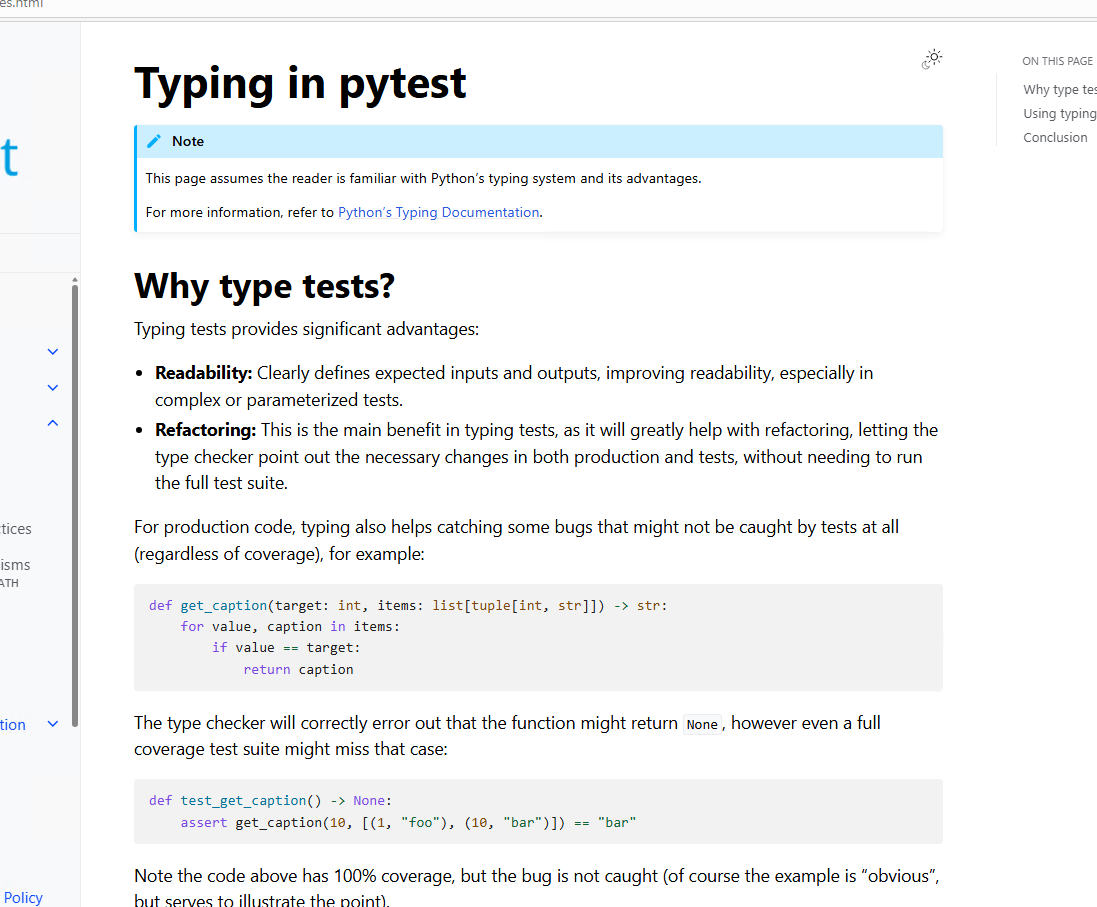


https://typing.python.org/en/latest/spec/annotations.html


